"""
# ChurnGuard - Customer Churn Prediction

**Objective**: Predict which bank customers are likely to churn (leave) so the bank can take preventive actions.

**Tech Stack**:
- Data Analysis: Pandas, NumPy, Matplotlib, Seaborn
- Modeling: Scikit-learn, XGBoost
- Tracking: MLflow
- Deployment: FastAPI + Docker

**Best Model**: XGBoost
"""

# 1 : Importing all libraries required for the Project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow
import os
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import shap

#hyperparameters for our models
import optuna

# Use SQLite (new recommended way)
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("ChurnGuard_Baseline")

print("✅ Using SQLite database")
print("Tracking URI:", mlflow.get_tracking_uri())

print("✅ All libraries imported successfully!")

/Users/amritanshudash/Desktop/ChurnGuard/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Using SQLite database
Tracking URI: sqlite:///mlflow.db
✅ All libraries imported successfully!


# 2 : Load Data + EDA

In [2]:
# Load the dataset
df = pd.read_csv("../data/churn_data.csv")

print("Shape of data:", df.shape)
print("\nColumns:", df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nChurn Rate:")
print(df['Exited'].value_counts())
print("Churn Percentage:", round(df['Exited'].mean()*100, 2), "%")

# Quick statistics
display(df.describe())

Shape of data: (10000, 14)

Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Missing Values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Churn Rate:
Exited
0    7963
1    2037
Name: count, dtype: int64
Churn Percentage: 20.37 %


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


# 3 : Visualizations

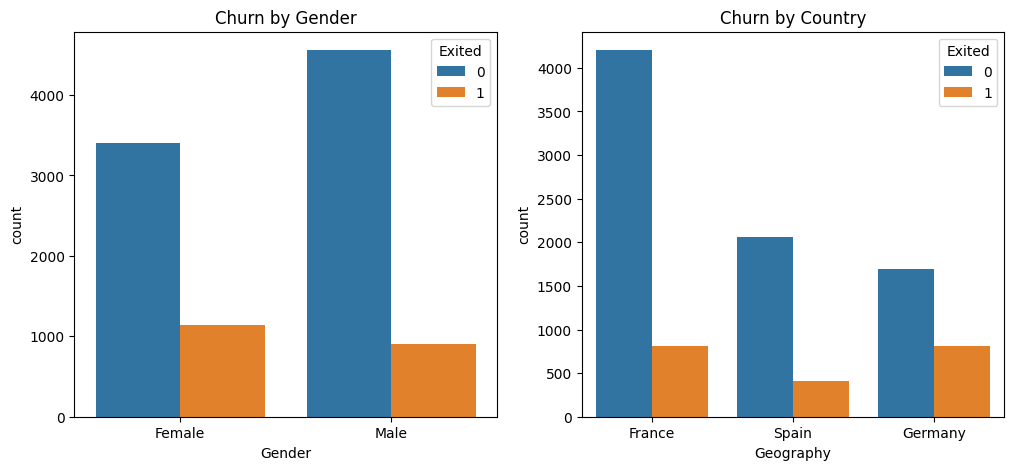

In [3]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.countplot(data=df, x='Gender', hue='Exited')
plt.title('Churn by Gender')

plt.subplot(1,2,2)
sns.countplot(data=df, x='Geography', hue='Exited')
plt.title('Churn by Country')

plt.show()

# 4 : Data Cleaning & Feature Engineering

In [4]:
# Drop useless columns
df = df.drop(columns=['RowNumber', 'Surname', 'CustomerId'])

# One-hot encoding
df = pd.get_dummies(df, columns=['Gender', 'Geography'], drop_first=True)

print("Columns after preprocessing:", df.columns.tolist())
display(df.head())

Columns after preprocessing: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Gender_Male', 'Geography_Germany', 'Geography_Spain']


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_Male,Geography_Germany,Geography_Spain
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,False,True
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,False,True


# 5 : Train-Test Split + Scaling

In [5]:
print(df.columns.tolist())
X = df.drop(columns=['Exited'])
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Gender_Male', 'Geography_Germany', 'Geography_Spain']
Training shape: (8000, 11)
Test shape: (2000, 11)


# 6 : Model Training with MLflow

In [6]:
models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, learning_rate=0.1, random_state=42)
}

for name, model in models.items():
    with mlflow.start_run(run_name=name):
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        mlflow.log_param("model", name)
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1_score", f1)
        
        print(f"{name} -> Accuracy: {acc:.4f} | F1: {f1:.4f}")

RandomForest -> Accuracy: 0.8695 | F1: 0.5915
XGBoost -> Accuracy: 0.8650 | F1: 0.6076


# 7 : Save Model + Scaler (New)

In [7]:
# Create model folder in root
model_dir = "../model"
os.makedirs(model_dir, exist_ok=True)

# Save best model (XGBoost) and scaler
joblib.dump(models["XGBoost"], f"{model_dir}/xgboost_model.pkl")
joblib.dump(scaler, f"{model_dir}/scaler.pkl")

print("✅ Model and Scaler saved successfully!")
print("Model path:", os.path.abspath(f"{model_dir}/xgboost_model.pkl"))

✅ Model and Scaler saved successfully!
Model path: /Users/amritanshudash/Desktop/ChurnGuard/model/xgboost_model.pkl


# 8 : SHAP - Explainability 

In [8]:
#Use our best model (XGBoost)
best_model = models["XGBoost"]

#Create shap explainer
explainer = shap.TreeExplainer(best_model)

#Calculate SHAP values for test set(only 200 samples for speed)
shap_values = explainer.shap_values(X_test_scaled[:200])

print("✅ SHAP values calculated successfully!")

✅ SHAP values calculated successfully!


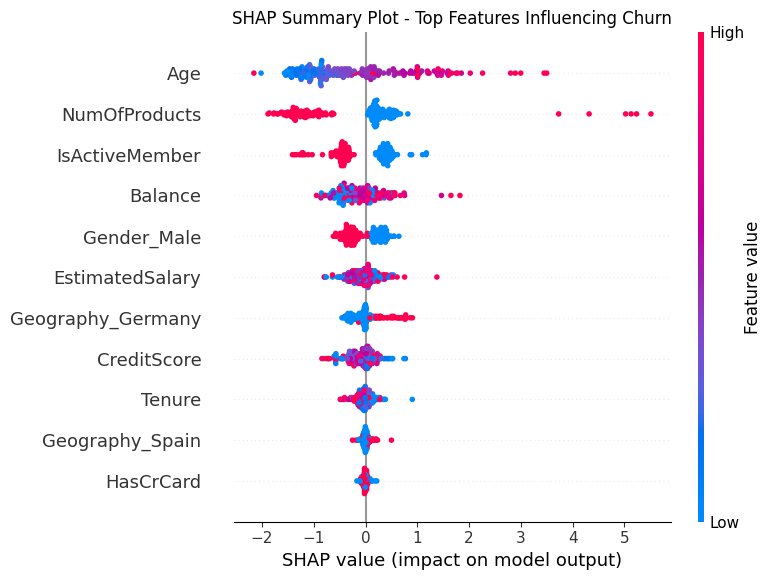

In [9]:
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X_test_scaled[:200], feature_names=X.columns.tolist(), show=False)
plt.title("SHAP Summary Plot - Top Features Influencing Churn")
plt.tight_layout()
plt.show()

<Figure size 1200x400 with 0 Axes>

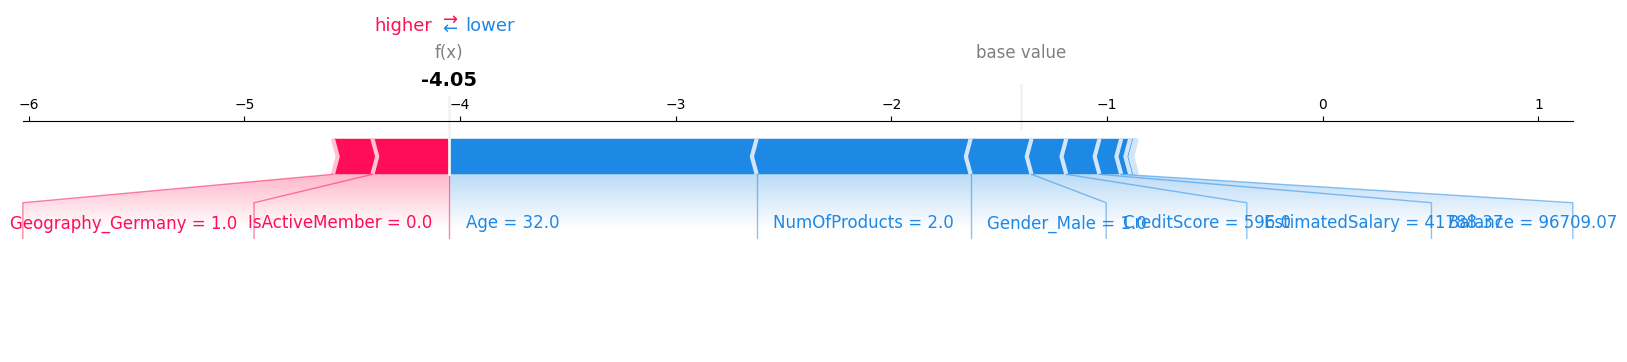

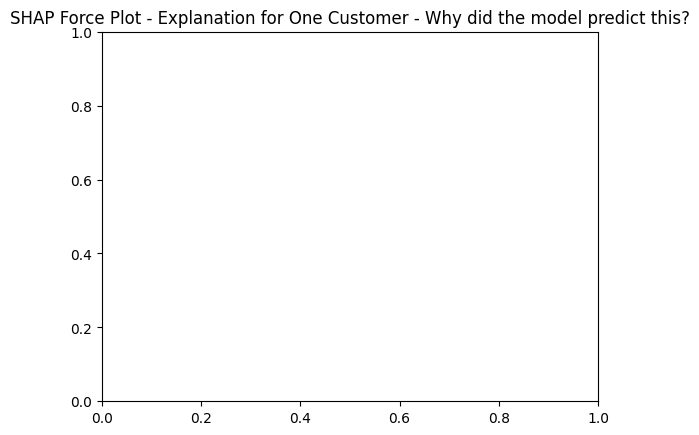

In [10]:
# Explanation for one customer (first one in test set)
plt.figure(figsize=(12, 4))
shap.force_plot(explainer.expected_value, shap_values[0], X_test.iloc[0], feature_names=X.columns.tolist(), matplotlib=True)
plt.title("SHAP Force Plot - Explanation for One Customer - Why did the model predict this?")
plt.show()    

# 9 : Hyperparameter Tuning

In [11]:
def objective(trial):
    #Define hyperparameters to tune
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
    }

    #Create model with these hyperparameters
    model = XGBClassifier(**params, random_state=42, use_label_encoder=False, eval_metric='logloss')

    #Use cross-validation to evaluate model performance
    scores = cross_val_score(model, X_train_scaled, y_train, cv=3, scoring='f1')
    return scores.mean()


In [16]:
#run optuna optimization study
study = optuna.create_study(direction='maximize')

#run optimization for 50 trials
study.optimize(objective, n_trials=100, show_progress_bar=True)

print("Best Hyperparameters:", study.best_params)
print("Best F1 Score:", study.best_value)

[I 2026-06-09 12:06:20,775] A new study created in memory with name: no-name-ff36be8b-238f-43b5-b441-848c716981ca
  0%|          | 0/100 [00:00<?, ?it/s]/Users/amritanshudash/Desktop/ChurnGuard/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:06:20] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/amritanshudash/Desktop/ChurnGuard/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:06:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/amritanshudash/Desktop/ChurnGuard/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:06:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=

[I 2026-06-09 12:06:21,430] Trial 0 finished with value: 0.5873036574224124 and parameters: {'n_estimators': 274, 'max_depth': 9, 'learning_rate': 0.10454741345929729, 'subsample': 0.9613064284448987, 'colsample_bytree': 0.6684526390409524, 'gamma': 1.1631313654928417, 'reg_alpha': 1.5189338678002868, 'reg_lambda': 1.359147219894115}. Best is trial 0 with value: 0.5873036574224124.


/Users/amritanshudash/Desktop/ChurnGuard/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:06:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/amritanshudash/Desktop/ChurnGuard/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:06:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 0. Best value: 0.587304:   2%|▏         | 2/100 [00:01<01:33,  1.05it/s]/Users/amritanshudash/Desktop/ChurnGuard/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:06:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/amritanshudash/Desktop/ChurnGuard/venv/lib/python3.14/sit

[I 2026-06-09 12:06:22,591] Trial 1 finished with value: 0.5804389629334924 and parameters: {'n_estimators': 410, 'max_depth': 4, 'learning_rate': 0.06775242326949976, 'subsample': 0.8456885365535445, 'colsample_bytree': 0.7959080122193924, 'gamma': 0.35215132930151827, 'reg_alpha': 1.0340231355605245, 'reg_lambda': 1.7779853956961378}. Best is trial 0 with value: 0.5873036574224124.


Best trial: 0. Best value: 0.587304:   3%|▎         | 3/100 [00:02<01:00,  1.60it/s]/Users/amritanshudash/Desktop/ChurnGuard/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:06:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/amritanshudash/Desktop/ChurnGuard/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:06:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


...

[I 2026-06-09 12:07:01,971] Trial 97 finished with value: 0.6005203033042917 and parameters: {'n_estimators': 195, 'max_depth': 7, 'learning_rate': 0.28578906020037487, 'subsample': 0.7906132189173176, 'colsample_bytree': 0.5633531886954531, 'gamma': 3.300675100819617, 'reg_alpha': 1.1124125842767336, 'reg_lambda': 3.6350734481402567}. Best is trial 82 with value: 0.6044194906738728.


Best trial: 82. Best value: 0.604419:  99%|█████████▉| 99/100 [00:41<00:00,  3.16it/s]/Users/amritanshudash/Desktop/ChurnGuard/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:07:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/amritanshudash/Desktop/ChurnGuard/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:07:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/amritanshudash/Desktop/ChurnGuard/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:07:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-06-09 12:07:02,304] Trial 98 finished with value: 0.5904241418121939 and parameters: {'n_estimators': 187, 'max_depth': 7, 'learning_rate': 0.2882686751849539, 'subsample': 0.8086172154250624, 'colsample_bytree': 0.5614399876334162, 'gamma': 3.122343237707996, 'reg_alpha': 0.9338978074947899, 'reg_lambda': 3.3481598018211685}. Best is trial 82 with value: 0.6044194906738728.


Best trial: 82. Best value: 0.604419: 100%|██████████| 100/100 [00:41<00:00,  2.39it/s]

[I 2026-06-09 12:07:02,570] Trial 99 finished with value: 0.5928228788803044 and parameters: {'n_estimators': 169, 'max_depth': 7, 'learning_rate': 0.29243870092523355, 'subsample': 0.7937654009915194, 'colsample_bytree': 0.5398293314624474, 'gamma': 2.9945637046807674, 'reg_alpha': 1.149661242816183, 'reg_lambda': 3.7003338765351677}. Best is trial 82 with value: 0.6044194906738728.
Best Hyperparameters: {'n_estimators': 228, 'max_depth': 5, 'learning_rate': 0.29272573656087536, 'subsample': 0.6912249610514146, 'colsample_bytree': 0.605819260072235, 'gamma': 3.9302774755445187, 'reg_alpha': 0.7814703781854041, 'reg_lambda': 3.0485327690758046}
Best F1 Score: 0.6044194906738728


In [17]:
# train best model with optimized hyperparameters
best_params = study.best_params

#train final model 
final_model = XGBClassifier(**best_params, random_state=42, use_label_encoder=False, eval_metric='logloss')
final_model.fit(X_train_scaled, y_train)

#Evaluate final model on test set
y_pred = final_model.predict(X_test_scaled)
f1 = f1_score(y_test, y_pred)

print(f"Final Model F1 Score: {f1:.4f}")

/Users/amritanshudash/Desktop/ChurnGuard/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:07:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Final Model F1 Score: 0.5976
